In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from pprint import pprint

In [10]:
train_path = r"../data/loan_payback/playground-series-s5e11/train.csv"
test_path = r"../data/loan_payback/playground-series-s5e11/test.csv"

In [3]:
get_input = lambda path: pd.read_csv(path)

In [16]:
df = get_input(train_path)

In [18]:
df.sort_values(by=['credit_score', 'annual_income'], ascending=[True, True])

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
81412,81412,41507.38,0.037,395,19130.11,13.18,Female,Single,Other,Employed,Debt consolidation,F2,0.0
190625,190625,64718.54,0.082,395,20652.35,16.19,Female,Married,Master's,Employed,Debt consolidation,F4,1.0
43281,43281,40562.00,0.195,431,25261.00,15.62,Female,Single,Bachelor's,Employed,Debt consolidation,F4,0.0
515778,515778,35424.95,0.109,435,24306.09,18.06,Female,Single,Bachelor's,Employed,Medical,F3,1.0
566406,566406,61250.52,0.080,435,12033.94,17.83,Male,Married,PhD,Employed,Education,F1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
201711,201711,73314.51,0.063,849,14953.02,7.35,Male,Married,High School,Employed,Other,A3,1.0
226805,226805,74544.75,0.069,849,12606.97,8.54,Female,Married,Other,Employed,Debt consolidation,A5,1.0
438547,438547,82222.13,0.146,849,17704.25,10.64,Female,Single,High School,Unemployed,Other,A1,1.0
79626,79626,85130.37,0.094,849,21404.81,7.26,Male,Single,Other,Employed,Debt consolidation,A4,1.0


In [20]:
df['loan_paid_back'].value_counts(normalize=True)

loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

In [21]:
df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442236,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [26]:
num_cols = ['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_paid_back']
cat_cols = [x for x in df.columns if x not in num_cols]

In [27]:
for i in cat_cols:
    print("*" * 10)
    print(pd.crosstab(df[i], df['loan_paid_back'], normalize='index'))

**********
loan_paid_back       0.0       1.0
gender                            
Female          0.198292  0.801708
Male            0.204248  0.795752
Other           0.204667  0.795333
**********
loan_paid_back       0.0       1.0
marital_status                    
Divorced        0.203360  0.796640
Married         0.200856  0.799144
Single          0.201127  0.798873
Widowed         0.210152  0.789848
**********
loan_paid_back        0.0       1.0
education_level                    
Bachelor's       0.211108  0.788892
High School      0.190302  0.809698
Master's         0.197654  0.802346
Other            0.197211  0.802789
PhD              0.169933  0.830067
**********
loan_paid_back          0.0       1.0
employment_status                    
Employed           0.105855  0.894145
Retired            0.002796  0.997204
Self-employed      0.101543  0.898457
Student            0.736485  0.263515
Unemployed         0.922381  0.077619
**********
loan_paid_back           0.0       1.0
loa

# Masaya Kawamata Solution Notebook

In [53]:
train = get_input(train_path)
test = get_input(test_path)
TARGET = 'loan_paid_back'
CATS = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
BASE = [col for col in train.columns if col not in ['id', TARGET]]

In [54]:
from itertools import combinations

INTER = []

for col1, col2 in combinations(BASE, 2):
    new_col_name = f'{col1}_{col2}'
    INTER.append(new_col_name)
    for df in [train, test, orig]:
        df[new_col_name] = df[col1].astype(str) + '_' + df[col2].astype(str)
        
print(f'{len(INTER)} Features.')

55 Features.


In [55]:
orig = train[:20000]
ORIG = []

for col in BASE:
    # MEAN
    mean_map = orig.groupby(col)[TARGET].mean()
    new_mean_col_name = f"orig_mean_{col}"
    mean_map.name = new_mean_col_name
    
    train = train.merge(mean_map, on=col, how='left')
    test = test.merge(mean_map, on=col, how='left')
    ORIG.append(new_mean_col_name)

    # COUNT
    new_count_col_name = f"orig_count_{col}"
    count_map = orig.groupby(col).size().reset_index(name=new_count_col_name)
    
    train = train.merge(count_map, on=col, how='left')
    test = test.merge(count_map, on=col, how='left')
    ORIG.append(new_count_col_name)

print(len(ORIG), 'Orig Features Created!!')

22 Orig Features Created!!


In [57]:
FEATURES = BASE + ORIG + INTER
print(len(FEATURES), 'Features.')

88 Features.


In [58]:
X = train[FEATURES]
y = train[TARGET]

In [59]:
from sklearn.model_selection import StratifiedKFold, KFold

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

In [60]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

In [65]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'max_depth': 5,
    'feature_fraction': 0.5,  # same as colsample_bytree
    'subsample': 0.8,
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'random_state': 42,
    'n_jobs': -1,
    'enable_categorical': True,
}


In [61]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed
oof_preds = np.zeros(len(X))


In [66]:
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{N_SPLITS} ---')
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test[FEATURES].copy()

    TE = TargetEncoder(cols_to_encode=INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
    X_train = TE.fit_transform(X_train, y_train)
    X_val = TE.transform(X_val)
    X_test = TE.transform(X_test)

    X_train[CATS] = X_train[CATS].astype('category')
    X_val[CATS] = X_val[CATS].astype('category')
    X_test[CATS] = X_test[CATS].astype('category')

    model = LGBMClassifier(**params)
    
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)])

    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    
    fold_score = roc_auc_score(y_val, val_preds)
    print(f'Fold {fold} AUC: {fold_score:.4f}')
    test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS

overall_auc = roc_auc_score(y, oof_preds)
print(f'====================')
print(f'Overall OOF AUC: {overall_auc:.4f}')
print(f'====================')

--- Fold 1/5 ---


C:\Users\16yas\AppData\Local\Temp\ipykernel_29776\2856352345.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\16yas\AppData\Local\Temp\ipykernel_29776\2856352345.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.075558 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13822
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 88
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM

C:\Users\16yas\AppData\Local\Temp\ipykernel_29776\2856352345.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\16yas\AppData\Local\Temp\ipykernel_29776\2856352345.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.055720 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13816
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 88
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM

...

[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059734 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13815
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 88
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM

C:\Users\16yas\AppData\Local\Temp\ipykernel_29776\2856352345.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\16yas\AppData\Local\Temp\ipykernel_29776\2856352345.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13812
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 88
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM

C:\Users\16yas\AppData\Local\Temp\ipykernel_29776\2856352345.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
C:\Users\16yas\AppData\Local\Temp\ipykernel_29776\2856352345.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] Number of positive: 379596, number of negative: 95600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054704 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13818
[LightGBM] [Info] Number of data points in the train set: 475196, number of used features: 88
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798820 -> initscore=1.378935
[LightGBM

In [68]:
import pickle

with open(r"../data/loan_payback/models/masaya_lgbm_model.pkl", 'wb') as f:
    pickle.dump(model, f)

ROC AUC: 0.9105991245217718
PR AUC: 0.9711395022817335
              precision    recall  f1-score   support

           0       0.63      0.77      0.69     23900
           1       0.94      0.88      0.91     94899

    accuracy                           0.86    118799
   macro avg       0.78      0.83      0.80    118799
weighted avg       0.88      0.86      0.87    118799

[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010185 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1597
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


d:\Dsoft\Projects\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGB ROC AUC: 0.9207536345291301
LGB PR AUC: 0.9746793801159283
              precision    recall  f1-score   support

           0       0.63      0.79      0.70     23900
           1       0.94      0.89      0.91     94899

    accuracy                           0.87    118799
   macro avg       0.79      0.84      0.81    118799
weighted avg       0.88      0.87      0.87    118799

Confusion matrix (th = 0.5):
 [[18320  5580]
 [ 8805 86094]]
                            feature   imp
1              debt_to_income_ratio  4256
2                      credit_score  2384
3                   log_loan_amount  1655
4                     interest_rate  1642
0                 log_annual_income  1461
5                    loan_to_income   999
6                       grade_digit   392
20        employment_status_Retired   276
22        employment_status_Student   251
23     employment_status_Unemployed   178
26  loan_purpose_Debt consolidation   116
14       education_level_Bachelor's    98
11 

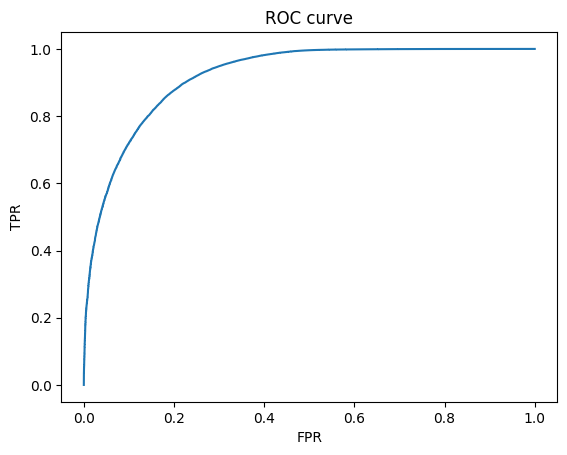

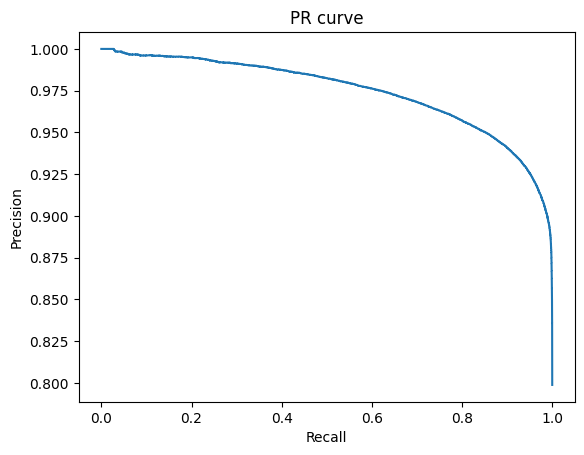

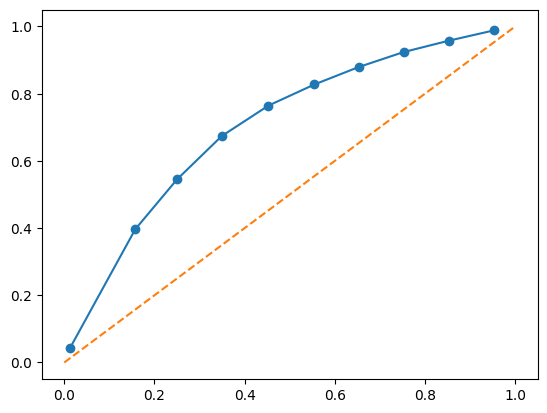

In [46]:
# standard libraries
import pandas as pd
import numpy as np

# viz
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             confusion_matrix, classification_report, brier_score_loss, roc_curve)

# optional: if you have lightgbm
import lightgbm as lgb

# 0. load
# df = pd.read_csv('yourfile.csv')  # replace

# 1. Basic feature engineering
df = get_input(train_path)
# split grade_subgrade into letter and digit
df['grade_letter'] = df['grade_subgrade'].str[0]
df['grade_digit'] = df['grade_subgrade'].str[1].astype(int)

# create ratio features
df['loan_to_income'] = df['loan_amount'] / (df['annual_income'] + 1e-6)
# log transforms for skewed vars
df['log_annual_income'] = np.log1p(df['annual_income'])
df['log_loan_amount'] = np.log1p(df['loan_amount'])

# 2. Define features and target
target = 'loan_paid_back'
features = ['log_annual_income', 'debt_to_income_ratio', 'credit_score',
            'log_loan_amount', 'interest_rate', 'loan_to_income',
            'gender', 'marital_status', 'education_level', 'employment_status',
            'loan_purpose', 'grade_letter', 'grade_digit']

X = df[features]
y = df[target].astype(int)

# 3. Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Preprocessing pipelines
num_cols = ['log_annual_income', 'debt_to_income_ratio', 'credit_score',
            'log_loan_amount', 'interest_rate', 'loan_to_income', 'grade_digit']
cat_onehot = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose']
cat_ord = ['grade_letter']  # if you want ordinal mapping; otherwise onehot here too

# If you do not know grade ordering, do OneHot on 'grade_letter' as well.

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_onehot + cat_ord)
], remainder='drop')

# 5. Baseline model: Logistic Regression
clf_lr = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga'))
])

clf_lr.fit(X_train, y_train)
y_pred_proba = clf_lr.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("PR AUC:", average_precision_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

# 6. Stronger model: LightGBM (recommended for speed & performance)
# convert categorical features indices for LGBM or let LGBM handle encoded features:
# We'll use preprocessed numeric + onehot to keep pipeline simple:
clf_lgb = Pipeline([
    ('preproc', preprocessor),
    ('clf', lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                               class_weight='balanced', random_state=42))
])
clf_lgb.fit(X_train, y_train)
y_proba_lgb = clf_lgb.predict_proba(X_test)[:, 1]

print("LGB ROC AUC:", roc_auc_score(y_test, y_proba_lgb))
print("LGB PR AUC:", average_precision_score(y_test, y_proba_lgb))
print(classification_report(y_test, (y_proba_lgb >= 0.5).astype(int)))

# 7. Evaluate thresholds, confusion matrix, and calibration
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lgb)
plt.figure()
plt.plot(fpr, tpr); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC curve')

# Precision-Recall
precision, recall, pr_thresh = precision_recall_curve(y_test, y_proba_lgb)
plt.figure()
plt.plot(recall, precision); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR curve')

# Confusion at chosen threshold
th = 0.45
cm = confusion_matrix(y_test, (y_proba_lgb >= th).astype(int))
print("Confusion matrix (th = 0.5):\n", cm)

# 8. Feature importances (for tree models)
# get preprocessed feature names
ohe = clf_lgb.named_steps['preproc'].named_transformers_['cat'].named_steps['onehot']
ohe_names = ohe.get_feature_names_out(cat_onehot + cat_ord)
feature_names = num_cols + list(ohe_names)
importances = clf_lgb.named_steps['clf'].feature_importances_
feat_imp = pd.DataFrame({'feature': feature_names, 'imp': importances}).sort_values('imp', ascending=False)
print(feat_imp.head(20))

# 9. Calibration check (optional)
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_proba_lgb, n_bins=10)
plt.figure(); plt.plot(prob_pred, prob_true, marker='o'); plt.plot([0,1],[0,1], linestyle='--')

# 10. Cross-validation & simple hyperparam search (example)
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("LGB CV ROC-AUC:", np.mean(cross_val_score(clf_lgb, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)))


In [32]:

df = get_input(test_path)
# split grade_subgrade into letter and digit
df['grade_letter'] = df['grade_subgrade'].str[0]
df['grade_digit'] = df['grade_subgrade'].str[1].astype(int)

# create ratio features
df['loan_to_income'] = df['loan_amount'] / (df['annual_income'] + 1e-6)
# log transforms for skewed vars
df['log_annual_income'] = np.log1p(df['annual_income'])
df['log_loan_amount'] = np.log1p(df['loan_amount'])

# 2. Define features and target
target = 'loan_paid_back'
features = ['log_annual_income', 'debt_to_income_ratio', 'credit_score',
            'log_loan_amount', 'interest_rate', 'loan_to_income',
            'gender', 'marital_status', 'education_level', 'employment_status',
            'loan_purpose', 'grade_letter', 'grade_digit']


# 4. Preprocessing pipelines
num_cols = ['log_annual_income', 'debt_to_income_ratio', 'credit_score',
            'log_loan_amount', 'interest_rate', 'loan_to_income', 'grade_digit']
cat_onehot = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose']
cat_ord = ['grade_letter']  # if you want ordinal mapping; otherwise onehot here too

# If you do not know grade ordering, do OneHot on 'grade_letter' as well.

y_proba_lgb = clf_lgb.predict_proba(df)[:, 1]


d:\Dsoft\Projects\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [42]:
y_proba_lgb
results = pd.DataFrame(get_input(test_path)['id'])
results['loan_paid_back'] = y_proba_lgb
results['loan_paid_back'] = results['loan_paid_back'] > 0.5
results['loan_paid_back'] = results['loan_paid_back'].astype(int)

In [43]:
results['loan_paid_back']

0         1
1         1
2         0
3         1
4         1
         ..
254564    1
254565    1
254566    1
254567    1
254568    1
Name: loan_paid_back, Length: 254569, dtype: int64

In [44]:
results.to_csv('../data/loan_payback/lgb_basic_predictions.csv', index=False)

In [70]:
with open(r"../data/loan_payback/models/clf_lgb_00.pkl", 'wb') as f:
    pickle.dump(clf_lgb, f)

with open(r"../data/loan_payback/models/clf_lr_00.pkl", 'wb') as f:
    pickle.dump(clf_lr, f)
